<a href="https://colab.research.google.com/github/Jbaner/OMDSModC_Capstone_Project/blob/main/OMDS_ModC_Week11_Banerjee_Jayeeta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:
datasource= "https://archive.ics.uci.edu/static/public/17/data.csv"

df_BreastCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_BreastCancer.sample(10, random_state=42) #printing random sample of 10 rows

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
204,87930,12.47,18.60,81.09,481.9,0.09965,0.10580,0.08005,0.03821,0.1925,...,24.64,96.05,677.9,0.14260,0.2378,0.2671,0.10150,0.3014,0.08750,B
70,859575,18.94,21.31,123.60,1130.0,0.09009,0.10290,0.10800,0.07951,0.1582,...,26.58,165.90,1866.0,0.11930,0.2336,0.2687,0.17890,0.2551,0.06589,M
131,8670,15.46,19.48,101.70,748.9,0.10920,0.12230,0.14660,0.08087,0.1931,...,26.00,124.90,1156.0,0.15460,0.2394,0.3791,0.15140,0.2837,0.08019,M
431,907915,12.40,17.68,81.47,467.8,0.10540,0.13160,0.07741,0.02799,0.1811,...,22.91,89.61,515.8,0.14500,0.2629,0.2403,0.07370,0.2556,0.09359,B
540,921385,11.54,14.44,74.65,402.9,0.09984,0.11200,0.06737,0.02594,0.1818,...,19.68,78.78,457.8,0.13450,0.2118,0.1797,0.06918,0.2329,0.08134,B
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.8681,0.9387,0.26500,0.4087,0.12400,M
369,9012000,22.01,21.90,147.20,1482.0,0.10630,0.19540,0.24480,0.15010,0.1824,...,25.80,195.00,2227.0,0.12940,0.3885,0.4756,0.24320,0.2741,0.08574,M
29,853201,17.57,15.05,115.00,955.1,0.09847,0.11570,0.09875,0.07953,0.1739,...,19.52,134.90,1227.0,0.12550,0.2812,0.2489,0.14560,0.2756,0.07919,M
81,8611161,13.34,15.86,86.49,520.0,0.10780,0.15350,0.11690,0.06987,0.1942,...,23.19,96.66,614.9,0.15360,0.4791,0.4858,0.17080,0.3527,0.10160,B
477,911673,13.90,16.62,88.97,599.4,0.06828,0.05319,0.02224,0.01339,0.1813,...,21.80,101.20,718.9,0.09384,0.2006,0.1384,0.06222,0.2679,0.07698,B


In [3]:
df_BreastCancer["Diagnosis"]=df_BreastCancer["Diagnosis"].map({"M":0, "B":1})

In [5]:

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

# Target and Features
X = df_BreastCancer.drop(["Diagnosis", "ID"], axis=1)
y = df_BreastCancer["Diagnosis"]

#scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [9]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5,
    metric="euclidean")

dbscan_labels = dbscan.fit_predict(X_scaled)

# Number of clusters
clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print("Number of clusters:", clusters)

print(
    "Noise points:",
    list(dbscan_labels).count(-1))

Number of clusters: 1
Noise points: 550


In [22]:
#Check Number of Clusters and Noise Points
unique, counts = np.unique(
    dbscan_labels,
    return_counts=True)

print(dict(zip(unique, counts)))

{np.int64(-1): np.int64(371), np.int64(0): np.int64(12), np.int64(1): np.int64(181), np.int64(2): np.int64(3), np.int64(3): np.int64(2)}


In [16]:
for eps in [0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 2.0]:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5,
        metric="euclidean")

    labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(
        "eps:",
        eps,
        "Clusters:",
        n_clusters,
        "Noise:",
        n_noise
    )

eps: 0.5 Clusters: 0 Noise: 569
eps: 0.7 Clusters: 0 Noise: 569
eps: 0.9 Clusters: 0 Noise: 569
eps: 1.1 Clusters: 0 Noise: 569
eps: 1.3 Clusters: 1 Noise: 564
eps: 1.5 Clusters: 1 Noise: 550
eps: 2.0 Clusters: 4 Noise: 371


In [19]:
#DBSCAN Silhouette Score
dbscan = DBSCAN(
    eps=2.0,
    min_samples=5,
    metric="euclidean")

dbscan_labels = dbscan.fit_predict(X_scaled)

mask = dbscan_labels != -1
n_clusters = len(
    set(dbscan_labels[mask]))

if n_clusters > 1:

    score = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask])

    print("DBSCAN Clusters:", n_clusters)
    print("DBSCAN Silhouette Score:", round(score,4))

else:
    print(
        "Silhouette score cannot be calculated."
        " DBSCAN found fewer than 2 clusters.")

DBSCAN Clusters: 4
DBSCAN Silhouette Score: 0.0978


In [27]:
#Stability Check

X_sample1, X_sample2 = train_test_split(
    X_scaled,
    test_size=0.2,
    random_state=42)

dbscan = DBSCAN(eps=2.0, min_samples=5)


labels1 = dbscan.fit_predict(X_sample1)
clusters1 = len(set(labels1)) - (1 if -1 in labels1 else 0)

print("Clusters in sample:",clusters1)

Clusters in sample: 2


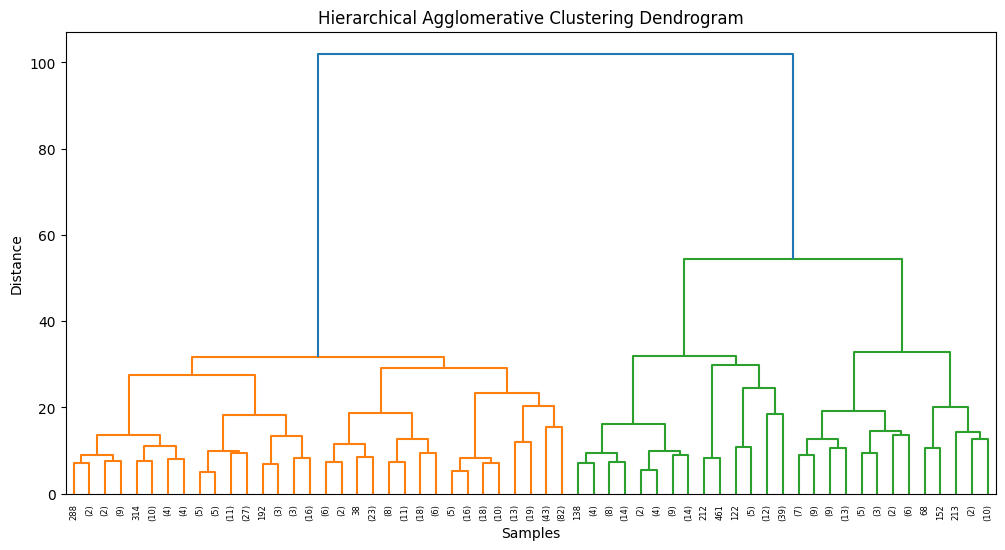

In [20]:
#Hierarchical Agglomerative Clustering
plt.figure(figsize=(12,6))

linked = linkage(
    X_scaled,
    method="ward")

dendrogram(
    linked,
    truncate_mode="level",
    p=5)

plt.title("Hierarchical Agglomerative Clustering Dendrogram")

plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

In [13]:
# linkage_methods
linkage_methods = ["ward","complete","average", "single"]

for method in linkage_methods:
    hac = AgglomerativeClustering(
        n_clusters=2,
        linkage=method)

    labels = hac.fit_predict(X_scaled)
    score = silhouette_score(
        X_scaled,
        labels)

    print( method,
        "Silhouette Score:",
        round(score,4))

ward Silhouette Score: 0.3394
complete Silhouette Score: 0.6607
average Silhouette Score: 0.634
single Silhouette Score: 0.6607


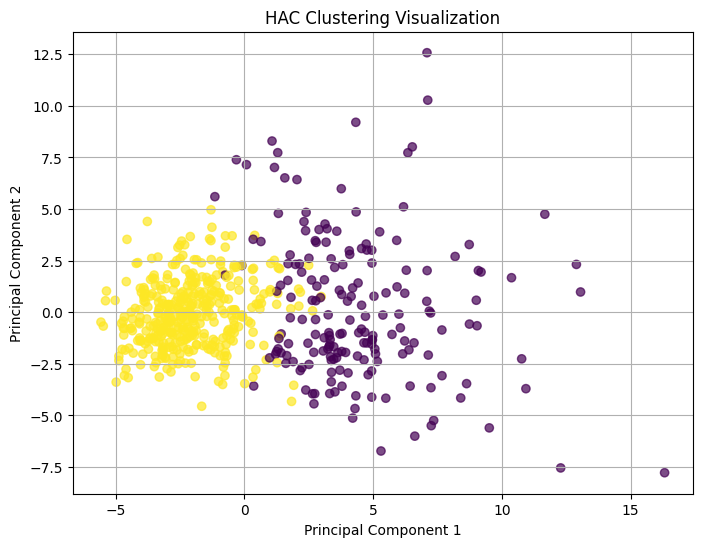

In [21]:
# AgglomerativeClustering
hac = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward")

hac_labels = hac.fit_predict(X_scaled)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=hac_labels,
    alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("HAC Clustering Visualization")

plt.grid(True)
plt.show()

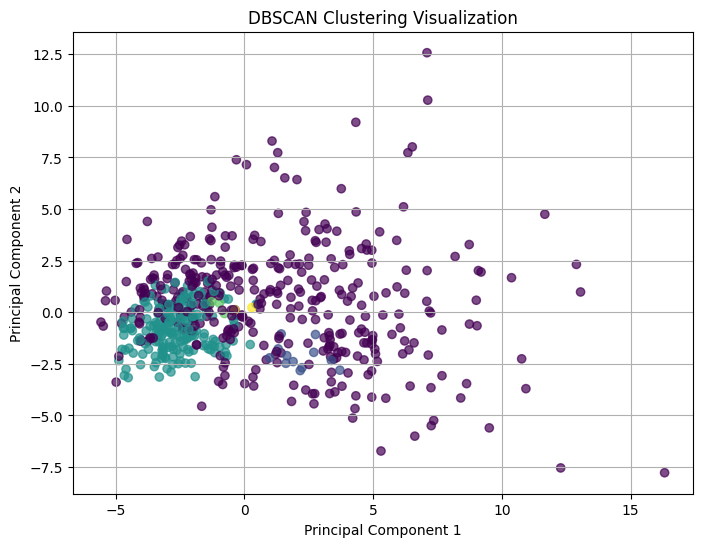

In [29]:
#Visualize DBSCAN Clusters Using PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_labels,
    alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clustering Visualization")

plt.grid(True)

plt.show()